In [6]:
# ==========================================
# Notebook 02
# Recommendation Data Exploration
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

In [7]:
items_df = pd.read_csv("../data/items.csv")

users_df = pd.read_csv("../data/users.csv")

interactions_df = pd.read_csv("../data/user_interactions.csv")

In [9]:
print("Items:", len(items_df))

print("Users:", len(users_df))

print("Interactions:", len(interactions_df))

Items: 10
Users: 5
Interactions: 14


In [10]:
items_df.head()

,item_id,title,category,description
0,1,The Early Days of Stripe,Startup,\n Story of how Stripe scaled into\n ...
1,2,Building SpaceX,Startup,"\n Deep dive into SpaceX,\n rock..."
2,3,AI for Healthcare,Artificial Intelligence,\n Applications of AI\n in healt...
3,4,The Psychology of Habits,Wellness,"\n Habit formation,\n behavior c..."
4,5,Cloud Computing Fundamentals,Technology,"\n Introduction to cloud platforms,\n ..."


In [11]:
interactions_df.head()

,user_id,item_id,rating
0,101,1,5
1,101,2,5
2,101,5,4
3,102,1,5
4,102,8,5


In [12]:
print("Unique Categories:", items_df["category"].nunique())

print()

items_df["category"].unique()

Unique Categories: 7



array(['Startup', 'Artificial Intelligence', 'Wellness', 'Technology',
       'Data Engineering', 'Machine Learning', 'Health'], dtype=object)

In [13]:
items_df["category"].value_counts()

category
Startup                    3
Artificial Intelligence    2
Wellness                   1
Technology                 1
Data Engineering           1
Machine Learning           1
Health                     1
Name: count, dtype: int64

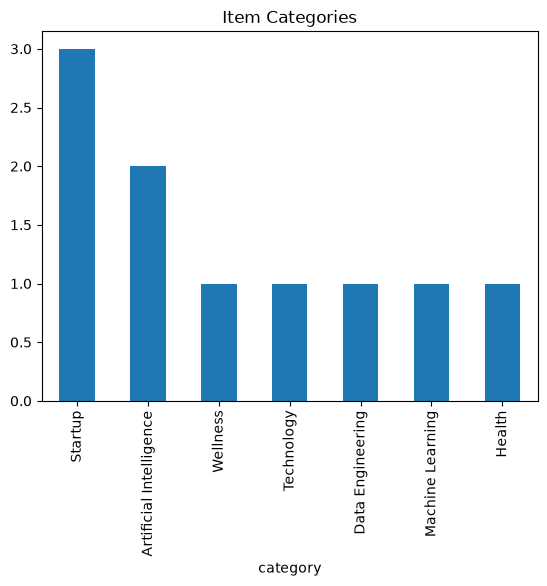

In [14]:
items_df["category"].value_counts().plot(kind="bar")

plt.title("Item Categories")

plt.show()

In [15]:
users_df["persona"].value_counts()

persona
Tech Enthusiast    1
Startup Founder    1
Health Reader      1
AI Researcher      1
Data Engineer      1
Name: count, dtype: int64

In [16]:
interactions_df.describe()

,user_id,item_id,rating
count,14.000000,14.000000,14.000000
mean,103.000000,5.000000,4.714286
std,1.519109,2.961289,0.468807
min,101.000000,1.000000,4.000000
25%,102.000000,2.250000,4.250000
50%,103.000000,5.000000,5.000000
75%,104.000000,7.000000,5.000000
max,105.000000,10.000000,5.000000


In [17]:
interactions_df["rating"].value_counts()

rating
5    10
4     4
Name: count, dtype: int64

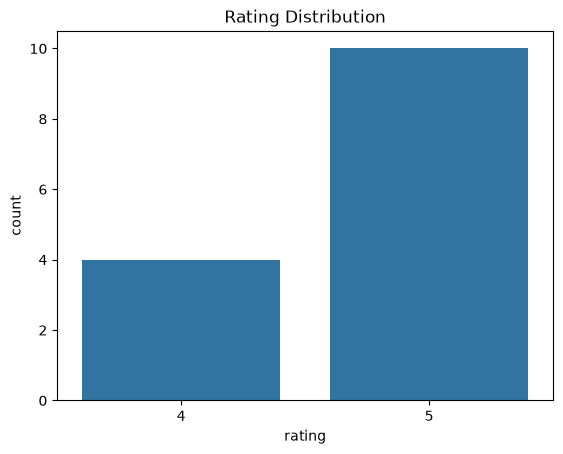

In [18]:
sns.countplot(x="rating", data=interactions_df)

plt.title("Rating Distribution")

plt.show()

In [19]:
interactions_df["rating"].mean()

4.714285714285714

In [20]:
user_activity = (
    interactions_df.groupby("user_id").size().reset_index(name="interaction_count")
)

user_activity

,user_id,interaction_count
0,101,3
1,102,3
2,103,2
3,104,3
4,105,3


In [21]:
user_activity.sort_values(by="interaction_count", ascending=False)

,user_id,interaction_count
0,101,3
1,102,3
3,104,3
4,105,3
2,103,2


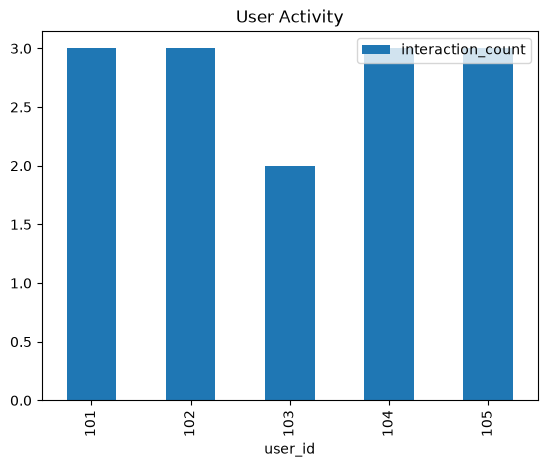

In [22]:
user_activity.plot(x="user_id", y="interaction_count", kind="bar")

plt.title("User Activity")

plt.show()

In [23]:
item_popularity = (
    interactions_df.groupby("item_id").size().reset_index(name="interaction_count")
)

item_popularity

,item_id,interaction_count
0,1,2
1,2,2
2,3,1
3,4,1
4,5,2
5,6,1
6,7,2
7,8,1
8,9,1
9,10,1


In [24]:
item_popularity = pd.merge(
    item_popularity, items_df[["item_id", "title"]], on="item_id"
)

item_popularity

,item_id,interaction_count,title
0,1,2,The Early Days of Stripe
1,2,2,Building SpaceX
2,3,1,AI for Healthcare
3,4,1,The Psychology of Habits
4,5,2,Cloud Computing Fundamentals
5,6,1,Modern Data Engineering
6,7,2,Machine Learning in Finance
7,8,1,Startup Fundraising Guide
8,9,1,Nutrition Science
9,10,1,Large Language Models


In [25]:
item_popularity.sort_values(by="interaction_count", ascending=False)

,item_id,interaction_count,title
0,1,2,The Early Days of Stripe
1,2,2,Building SpaceX
4,5,2,Cloud Computing Fundamentals
6,7,2,Machine Learning in Finance
2,3,1,AI for Healthcare
3,4,1,The Psychology of Habits
5,6,1,Modern Data Engineering
7,8,1,Startup Fundraising Guide
8,9,1,Nutrition Science
9,10,1,Large Language Models


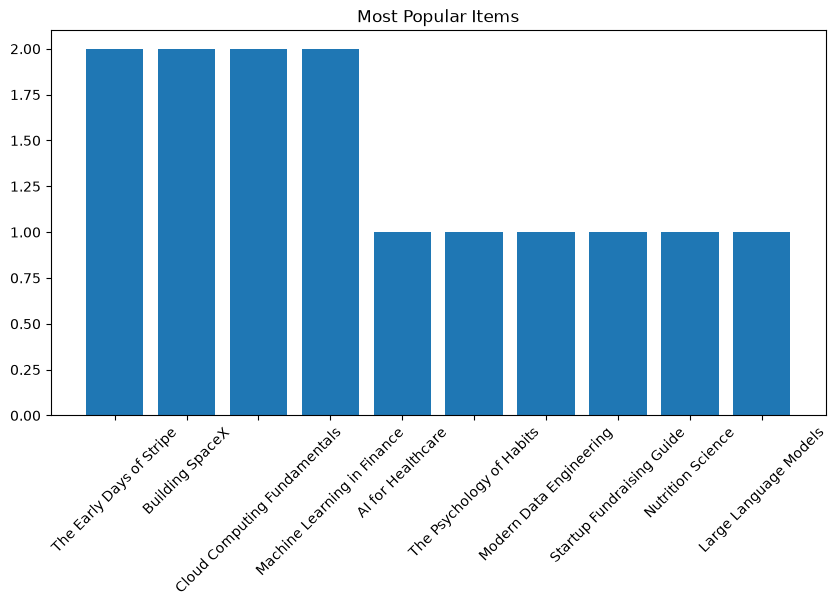

In [26]:
top_items = item_popularity.sort_values(by="interaction_count", ascending=False)

plt.figure(figsize=(10, 5))

plt.bar(top_items["title"], top_items["interaction_count"])

plt.xticks(rotation=45)

plt.title("Most Popular Items")

plt.show()

In [27]:
item_ratings = interactions_df.groupby("item_id")["rating"].mean().reset_index()

item_ratings

,item_id,rating
0,1,5.0
1,2,4.5
2,3,5.0
3,4,5.0
4,5,4.5
5,6,5.0
6,7,4.0
7,8,5.0
8,9,5.0
9,10,5.0


In [28]:
item_ratings = pd.merge(item_ratings, items_df[["item_id", "title"]], on="item_id")

item_ratings

,item_id,rating,title
0,1,5.0,The Early Days of Stripe
1,2,4.5,Building SpaceX
2,3,5.0,AI for Healthcare
3,4,5.0,The Psychology of Habits
4,5,4.5,Cloud Computing Fundamentals
5,6,5.0,Modern Data Engineering
6,7,4.0,Machine Learning in Finance
7,8,5.0,Startup Fundraising Guide
8,9,5.0,Nutrition Science
9,10,5.0,Large Language Models


In [29]:
item_ratings.sort_values(by="rating", ascending=False)

,item_id,rating,title
0,1,5.0,The Early Days of Stripe
2,3,5.0,AI for Healthcare
3,4,5.0,The Psychology of Habits
5,6,5.0,Modern Data Engineering
7,8,5.0,Startup Fundraising Guide
8,9,5.0,Nutrition Science
9,10,5.0,Large Language Models
1,2,4.5,Building SpaceX
4,5,4.5,Cloud Computing Fundamentals
6,7,4.0,Machine Learning in Finance


In [30]:
user_history = pd.merge(interactions_df, items_df, on="item_id")

user_history

,user_id,item_id,rating,title,category,description
0,101,1,5,The Early Days of Stripe,Startup,\n Story of how Stripe scaled into\n ...
1,101,2,5,Building SpaceX,Startup,"\n Deep dive into SpaceX,\n rock..."
2,101,5,4,Cloud Computing Fundamentals,Technology,"\n Introduction to cloud platforms,\n ..."
3,102,1,5,The Early Days of Stripe,Startup,\n Story of how Stripe scaled into\n ...
4,102,8,5,Startup Fundraising Guide,Startup,"\n Venture capital,\n seed fundi..."
5,102,2,4,Building SpaceX,Startup,"\n Deep dive into SpaceX,\n rock..."
6,103,4,5,The Psychology of Habits,Wellness,"\n Habit formation,\n behavior c..."
7,103,9,5,Nutrition Science,Health,"\n Diet,\n nutrition,\n a..."
8,104,3,5,AI for Healthcare,Artificial Intelligence,\n Applications of AI\n in healt...
9,104,10,5,Large Language Models,Artificial Intelligence,"\n Transformers,\n LLMs,\n ..."


In [31]:
user_history[user_history["user_id"] == 101]

,user_id,item_id,rating,title,category,description
0,101,1,5,The Early Days of Stripe,Startup,\n Story of how Stripe scaled into\n ...
1,101,2,5,Building SpaceX,Startup,"\n Deep dive into SpaceX,\n rock..."
2,101,5,4,Cloud Computing Fundamentals,Technology,"\n Introduction to cloud platforms,\n ..."


In [32]:
user_history[user_history["user_id"] == 102]

,user_id,item_id,rating,title,category,description
3,102,1,5,The Early Days of Stripe,Startup,\n Story of how Stripe scaled into\n ...
4,102,8,5,Startup Fundraising Guide,Startup,"\n Venture capital,\n seed fundi..."
5,102,2,4,Building SpaceX,Startup,"\n Deep dive into SpaceX,\n rock..."


In [33]:
user_history[user_history["user_id"] == 104]

,user_id,item_id,rating,title,category,description
8,104,3,5,AI for Healthcare,Artificial Intelligence,\n Applications of AI\n in healt...
9,104,10,5,Large Language Models,Artificial Intelligence,"\n Transformers,\n LLMs,\n ..."
10,104,7,4,Machine Learning in Finance,Machine Learning,"\n Predictive analytics,\n finan..."


In [34]:
interaction_matrix = interactions_df.pivot_table(
    index="user_id", columns="item_id", values="rating"
)

interaction_matrix

item_id,1,2,3,4,5,6,7,8,9,10
user_id,,,,,,,,,,
101,5.0,5.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN
102,5.0,4.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN
103,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,5.0,NaN
104,NaN,NaN,5.0,NaN,NaN,NaN,4.0,NaN,NaN,5.0
105,NaN,NaN,NaN,NaN,5.0,5.0,4.0,NaN,NaN,NaN


In [35]:
total_cells = interaction_matrix.shape[0] * interaction_matrix.shape[1]

filled_cells = interaction_matrix.count().sum()

density = filled_cells / total_cells


density

0.28

In [36]:
sparsity = 1 - density

print("Sparsity:", round(sparsity, 4))

Sparsity: 0.72


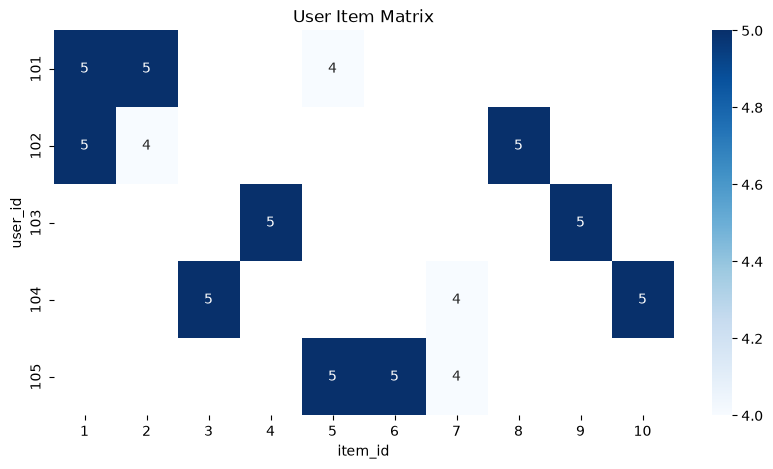

In [37]:
plt.figure(figsize=(10, 5))

sns.heatmap(interaction_matrix, annot=True, cmap="Blues")

plt.title("User Item Matrix")

plt.show()

In [38]:
category_popularity = pd.merge(interactions_df, items_df, on="item_id")

category_popularity.groupby("category").size()

category
Artificial Intelligence    2
Data Engineering           1
Health                     1
Machine Learning           2
Startup                    5
Technology                 2
Wellness                   1
dtype: int64

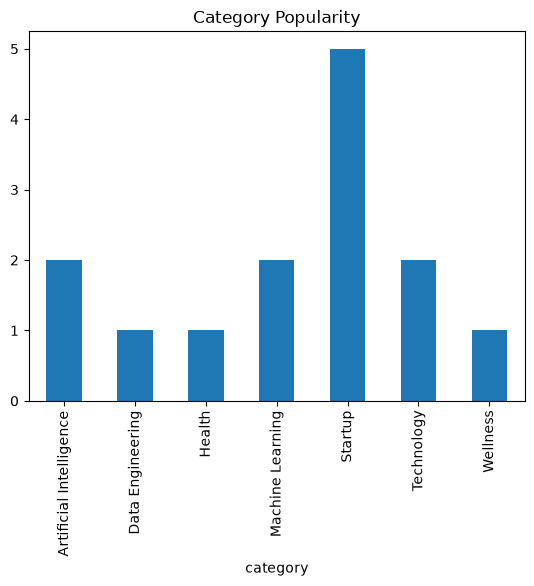

In [39]:
category_popularity.groupby("category").size().plot(kind="bar")

plt.title("Category Popularity")

plt.show()

In [40]:
statistics_df = pd.DataFrame(
    {
        "metric": [
            "total_items",
            "total_users",
            "total_interactions",
            "avg_rating",
            "sparsity",
        ],
        "value": [
            len(items_df),
            len(users_df),
            len(interactions_df),
            interactions_df["rating"].mean(),
            sparsity,
        ],
    }
)

statistics_df

,metric,value
0,total_items,10.000000
1,total_users,5.000000
2,total_interactions,14.000000
3,avg_rating,4.714286
4,sparsity,0.720000


In [41]:
statistics_df.to_csv("../data/interaction_statistics.csv", index=False)

In [42]:
item_popularity.to_csv("../data/item_popularity.csv", index=False)

In [43]:
user_activity.to_csv("../data/user_activity.csv", index=False)

In [44]:
saved_df = pd.read_csv("../data/interaction_statistics.csv")

saved_df

,metric,value
0,total_items,10.000000
1,total_users,5.000000
2,total_interactions,14.000000
3,avg_rating,4.714286
4,sparsity,0.720000
